In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    accuracy_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [11]:
# If running in Kaggle, upload file to /kaggle/input/ folder
DATA_PATH = "D:\Final Project\Buildable-ML-DL-Fellowship\Final_project\data\Crop_recommendation.csv"

df = pd.read_csv(DATA_PATH)
print("Dataset Loaded Successfully")
df.head()


Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [12]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
df.describe()


Shape: (2200, 8)

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Data Types:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


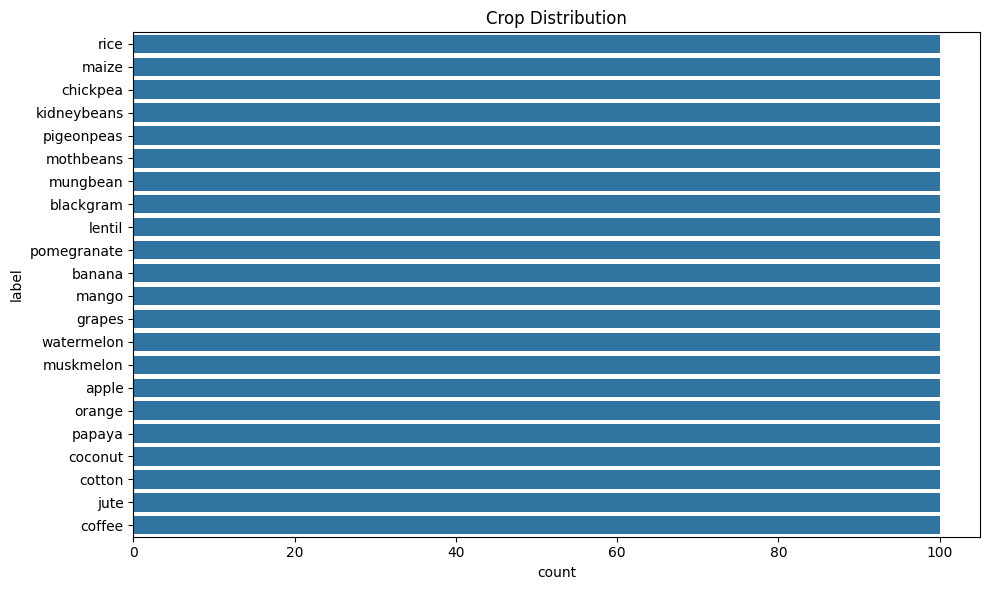

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(y=df['label'], order=df['label'].value_counts().index)
plt.title("Crop Distribution")
plt.tight_layout()
plt.show()


In [14]:
# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Feature Engineering Required by Assignment
df['soil_fertility'] = (df['n'] + df['p'] + df['k']) / 3
df['climate_index'] = df['temperature'] * df['humidity']

# Encode label (target)
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("Crop Classes:", list(le.classes_))


Crop Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


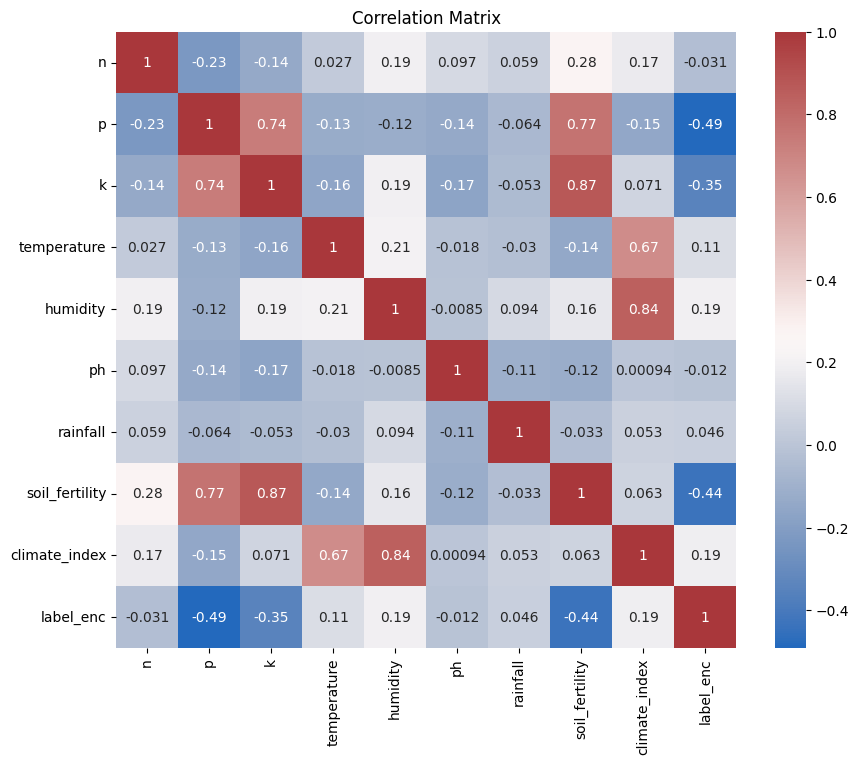

In [15]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="vlag")
plt.title("Correlation Matrix")
plt.show()


In [16]:
feature_cols = [
    'n','p','k','temperature','humidity','ph','rainfall',
    'soil_fertility','climate_index'
]

X = df[feature_cols]
y = df['label_enc']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done.")


Scaling done.


In [17]:
# Step 1: train+val vs test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Step 2: from remaining 85%, take 15% val
val_size = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (1540, 9)
Validation: (330, 9)
Test: (330, 9)


# Logistic Regression

In [18]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

y_val_pred_lr = lr.predict(X_val)

print("Logistic Regression Validation Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print(classification_report(y_val, y_val_pred_lr, target_names=le.classes_))


Logistic Regression Validation Accuracy: 0.9757575757575757
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       0.83      1.00      0.91        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.87      0.87      0.87        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      0.93      0.97        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      0.93      0.97        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.

# Random Forest

In [27]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_val_pred_rf = rf.predict(X_val)

print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print(classification_report(y_val, y_val_pred_rf, target_names=le.classes_))


Random Forest Validation Accuracy: 1.0
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       1.00      1.00      1.00        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.0

# Choosing best model based on Validation

TEST Accuracy: 0.9939393939393939
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      0.93      0.97        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       0.94      1.00      0.97        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00    

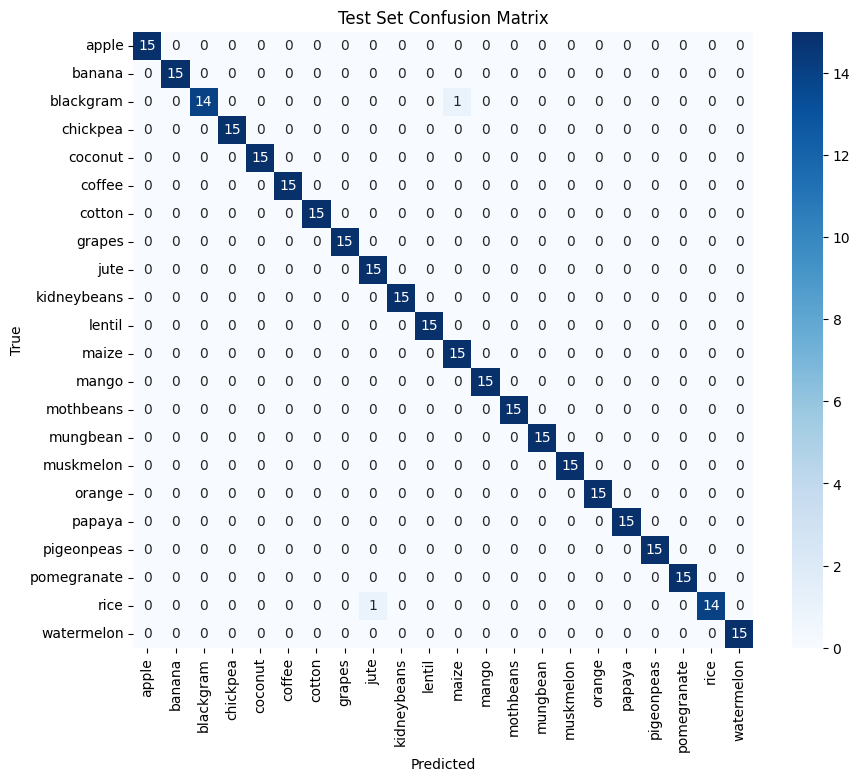

In [20]:
# Choose best model based on validation performance
best_model = rf  # (replace with lr if LR performs better)

y_test_pred = best_model.predict(X_test)

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [21]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/crop_model.pkl")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(le, "models/label_encoder.joblib")

print("Model, Scaler & Label Encoder Saved Successfully")


Model, Scaler & Label Encoder Saved Successfully


# Inference


In [26]:
sample = {
    'n': 90,
    'p': 42,
    'k': 43,
    'temperature': 21,
    'humidity': 80,
    'ph': 6.5,
    'rainfall': 200
}

sample_df = pd.DataFrame([sample])
sample_df['soil_fertility'] = (sample_df['n'] + sample_df['p'] + sample_df['k'])/3
sample_df['climate_index'] = sample_df['temperature'] * sample_df['humidity']

sample_X = sample_df[feature_cols]

scaler_loaded = joblib.load("models/scaler.joblib")
model_loaded = joblib.load("models/crop_model.pkl")
le_loaded = joblib.load("models/label_encoder.joblib")

sample_scaled = scaler_loaded.transform(sample_X)
pred_enc = model_loaded.predict(sample_scaled)
pred_crop = le_loaded.inverse_transform(pred_enc)

print("Predicted Crop:", pred_crop[0])


Predicted Crop: rice
